### This notebook contains a binary classification example for SAFE-AI metrics using the HMDA credit lending dataset sample. The target variable is 'action_taken' (0 and 1)

In [1]:
!git clone https://github.com/koleso500/safeai.git
import sys
sys.path.append("safeai")

Cloning into 'safeai'...


In [2]:
import pandas as pd
import numpy as np
import warnings
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import auc

from safe.rga import compare_models_rga
from safe.rgr import compare_models_rgr
from safe.rge import compare_models_rge_tabular
from safe.utils import align_proba_to_class_order



warnings.filterwarnings('ignore')
pd.set_option("display.max_rows", 1000)
pd.set_option("display.max_columns", 10000)

In [3]:
data = pd.read_csv("data_clean_ny_2017_sample.csv") 
print("This dataset has {} rows and {} columns".format(data.shape[0], data.shape[1]))
data.head()

This dataset has 17147 rows and 21 columns


,loan_type,loan_purpose,loan_amount_000s,action_taken,msamd,county_code,census_tract_number,applicant_ethnicity,co_applicant_ethnicity,applicant_race_1,co_applicant_race_1,applicant_sex,co_applicant_sex,applicant_income_000s,lien_status,population,minority_population,hud_median_family_income,tract_to_msamd_income,number_of_owner_occupied_units,number_of_1_to_4_family_units
0,1,3,300,1,35004.0,103.0,1233.01,2,5,5,8,1,5,540.0,1,8553.0,92.449997,110800.0,76.589996,1475.0,2258.0
1,1,3,200,1,28740.0,111.0,9537.00,2,2,5,5,1,2,41.0,1,5492.0,14.460000,78500.0,131.009995,1557.0,2061.0
2,1,2,51,1,10580.0,93.0,208.00,2,5,5,8,2,5,38.0,1,3341.0,62.020000,83100.0,49.139999,323.0,1627.0
3,1,1,292,0,35004.0,59.0,4132.00,2,5,5,8,2,5,135.0,1,5946.0,9.650000,110800.0,88.769997,2079.0,2297.0
4,1,1,472,0,35614.0,47.0,610.03,2,2,5,5,1,2,337.0,1,1838.0,68.879997,73700.0,75.639999,172.0,450.0


In [4]:
print(data["action_taken"].value_counts())

x = data.drop("action_taken", axis=1)
y_class = data["action_taken"]

x_train, x_test, ytrain_cl, ytest_cl = train_test_split(x, y_class, test_size=0.3, random_state=42)

action_taken
0    13997
1     3150
Name: count, dtype: int64


In [5]:
# Shared order for all comparisons
class_order = np.array([0, 1])

# Model 1
rf = RandomForestClassifier(random_state=123)
rf.fit(x_train, ytrain_cl)
rf_prob_raw = rf.predict_proba(x_test)
rf_prob = align_proba_to_class_order(rf_prob_raw, rf.classes_, class_order)

# Model 2
lr = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=123)
lr.fit(x_train, ytrain_cl)
lr_prob_raw = lr.predict_proba(x_test)
lr_prob = align_proba_to_class_order(lr_prob_raw, lr.classes_, class_order)

y_true = np.asarray(ytest_cl, dtype=int)

### RGA and AURGA


Evaluating RF...
RGA Evaluation: RF
Full RGA: 0.7155
AURGA: 0.2622
AURGA_perfect: 0.9500
AURGA_normalized_to_perfect: 0.2760

Class order: [0 1]

Per-Class RGA:
Class 0: RGA=0.7298, Weight=0.8206
Class 1: RGA=0.6506, Weight=0.1794

Evaluating LR...
RGA Evaluation: LR
Full RGA: 0.6306
AURGA: 0.1907
AURGA_perfect: 0.9500
AURGA_normalized_to_perfect: 0.2008

Class order: [0 1]

Per-Class RGA:
Class 0: RGA=0.6399, Weight=0.8206
Class 1: RGA=0.5883, Weight=0.1794


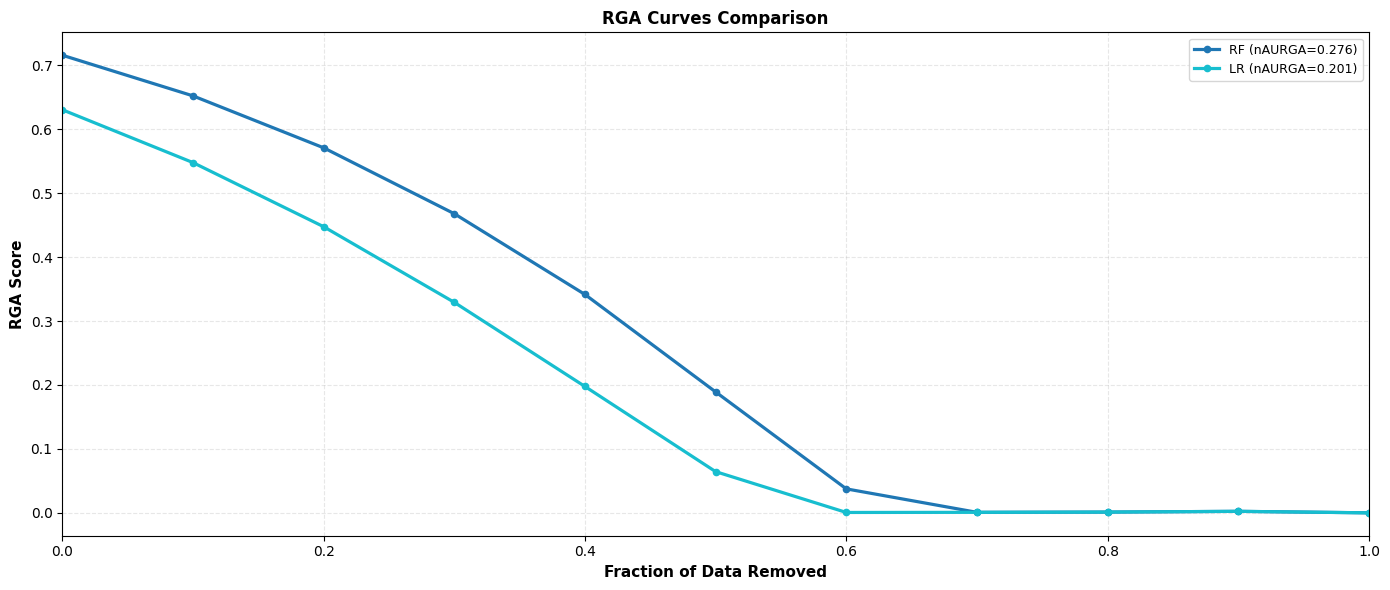


RGA Comparison Summary
RF: RGA=0.7155, AURGA=0.2622, nAURGA=0.2760
LR: RGA=0.6306, AURGA=0.1907, nAURGA=0.2008


In [6]:
models = {
    "RF": (rf_prob, class_order),
    "LR": (lr_prob, class_order)
}

rga = compare_models_rga(
    models_dict=models,
    y_labels=y_true,
    n_segments=10,
    verbose=True
)

### RGR


Evaluating RF...
RGR Evaluation: RF
Testing 11 noise levels
σ = 0.000: RGR = 1.0000
σ = 0.200: RGR = 0.9954
σ = 0.400: RGR = 0.9492
σ = 0.600: RGR = 0.9093
σ = 0.800: RGR = 0.8647
σ = 1.000: RGR = 0.8485
AURGR: 0.6635

Evaluating LR...
RGR Evaluation: LR
Testing 11 noise levels
σ = 0.000: RGR = 1.0000
σ = 0.200: RGR = 0.9990
σ = 0.400: RGR = 0.9959
σ = 0.600: RGR = 0.9911
σ = 0.800: RGR = 0.9841
σ = 1.000: RGR = 0.9771
AURGR: 0.6254


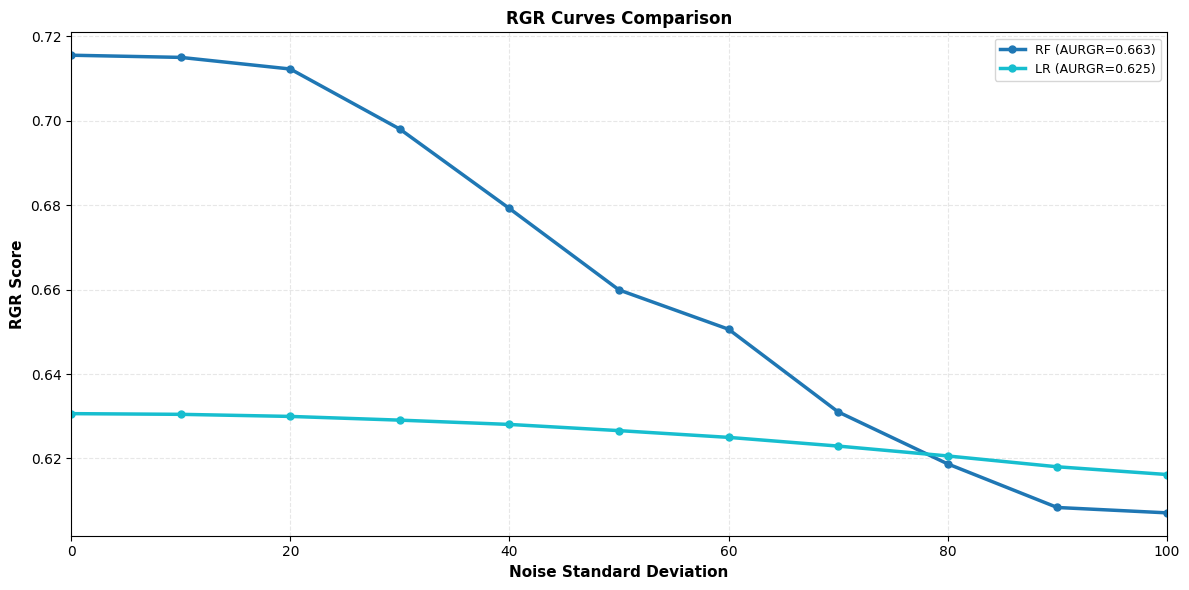

Robustness Comparison Summary
RF: AURGR = 0.6635
LR: AURGR = 0.6254
Best: RF (AURGR=0.6635)
Worst: LR (AURGR=0.6254)


In [7]:
# Noise levels
noise_levels = np.linspace(0.0, 1.0, 11)

models_rgr = {
    "RF": (rf, x_test.values, rf_prob, rf.classes_, "sklearn", None),
    "LR": (lr, x_test.values, lr_prob, lr.classes_, "sklearn", None)
}

rga_dict = {
    "RF": rga["RF"]["rga_full"],
    "LR": rga["LR"]["rga_full"],
}

rgr = compare_models_rgr(
    models_dict=models_rgr,
    noise_levels=noise_levels,
    class_order=class_order,
    rga_dict=rga_dict,
    verbose=True,
    random_seed=42
)

### RGE


Evaluating RGE (tabular) for RF
[RGE-tabular] step 1/20 | removed=0
picked: lien_status | rge=0.9984
[RGE-tabular] step 2/20 | removed=1
picked: applicant_sex | rge=0.9945
[RGE-tabular] step 3/20 | removed=2
picked: loan_type | rge=0.9882
[RGE-tabular] step 4/20 | removed=3
picked: applicant_ethnicity | rge=0.9757
[RGE-tabular] step 5/20 | removed=4
picked: co_applicant_race_1 | rge=0.9622
[RGE-tabular] step 6/20 | removed=5
picked: msamd | rge=0.9466
[RGE-tabular] step 7/20 | removed=6
picked: co_applicant_sex | rge=0.9259
[RGE-tabular] step 8/20 | removed=7
picked: county_code | rge=0.9010
[RGE-tabular] step 9/20 | removed=8
picked: population | rge=0.8747
[RGE-tabular] step 10/20 | removed=9
picked: hud_median_family_income | rge=0.8603
[RGE-tabular] step 11/20 | removed=10
picked: census_tract_number | rge=0.8322
[RGE-tabular] step 12/20 | removed=11
picked: minority_population | rge=0.8007
[RGE-tabular] step 13/20 | removed=12
picked: number_of_1_to_4_family_units | rge=0.7746
[R

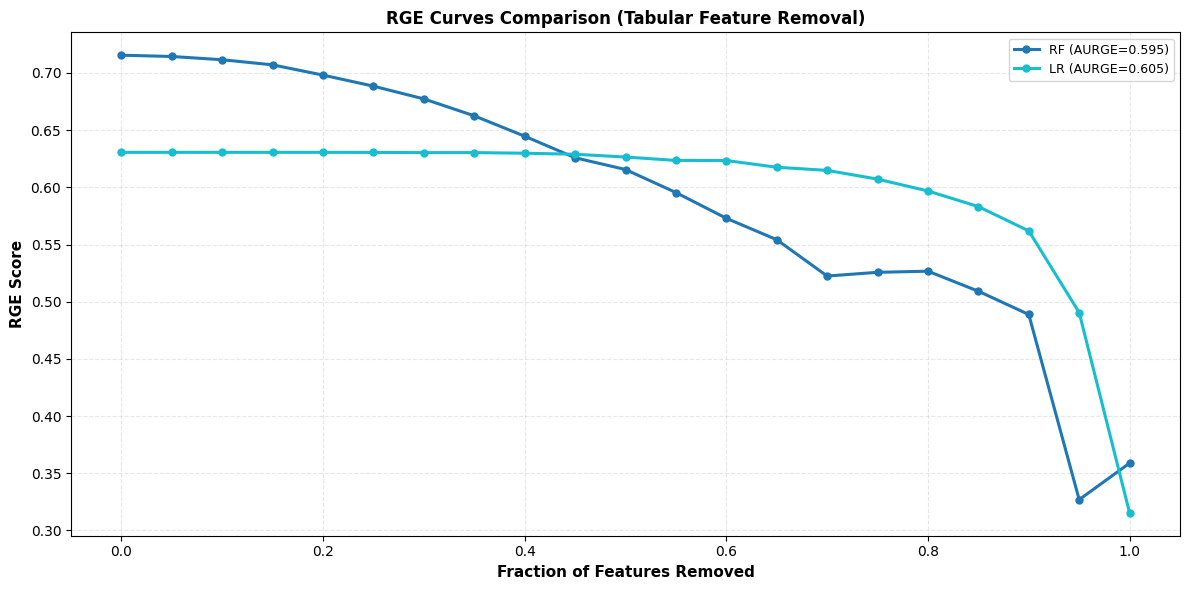


Explainability Comparison Summary (AURGE)
RF             : AURGE=0.5953
LR             : AURGE=0.6046


In [8]:
feature_names = list(x_test.columns)

models_rge = {
    "RF": (rf, x_test.values, feature_names, rf_prob, rf.classes_, "sklearn", None),
    "LR": (lr, x_test.values, feature_names, lr_prob, lr.classes_, "sklearn", None),
}

rge = compare_models_rge_tabular(
    models_dict=models_rge,
    class_order=class_order,
    rga_dict=rga_dict,       
    masking_method="greedy",                       
    n_steps=x_test.shape[1],
    verbose=True,
    random_seed=42
)